In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import *
from sklearn.metrics import *
from transformers import BertTokenizer, BertForSequenceClassification,Trainer, TrainingArguments
from datasets import Dataset



In [ ]:
df = pd.read_csv("/content/drive/MyDrive/mini project/testing.csv")
df.dropna(inplace = True)
print(df)

       Unnamed: 0                                          statement  \
0               0                                         oh my gosh   
1               1  trouble sleeping confused mind restless heart....   
2               2  all wrong back off dear forward doubt. stay in...   
3               3  ive shifted my focus to something else but im ...   
4               4  im restless and restless its been a month now ...   
...           ...                                                ...   
56333       56333  certainly didnt think reaching reddit express ...   
56334       56334  exactly title say young teenager transgender n...   
56335       56335  three failed attempt feel like biggest loser w...   
56336       56336  anymore ive attempted suicide past pill booze ...   
56337       56337  feel like lose fucking mind hate staying fucki...   

             status                                    lemmatized_text  
0           anxiety                                         oh

In [ ]:
df.drop(columns=['Unnamed: 0', 'lemmatized_text'], axis=1, inplace=True)
df.head()

,statement,status
0,oh my gosh,anxiety
1,trouble sleeping confused mind restless heart....,anxiety
2,all wrong back off dear forward doubt. stay in...,anxiety
3,ive shifted my focus to something else but im ...,anxiety
4,im restless and restless its been a month now ...,anxiety


In [ ]:
df['status'].value_counts()

,count
status,
suicidewatch,13898
anxiety,13617
depression,13087
normal,12297
mental_disorder,3396


In [ ]:
import re
import nltk

In [ ]:
def clean_statement(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)       # remove URLs
    text = re.sub(r'@\w+', '', text)          # remove @mentions
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # remove special symbols
    text = re.sub(r'\s+', ' ', text).strip()  # normalize whitespace
    return text

In [ ]:
df['statement'] = df['statement'].apply(clean_statement)
df.head()

,statement,status
0,oh my gosh,anxiety
1,trouble sleeping confused mind restless heart ...,anxiety
2,all wrong back off dear forward doubt stay in ...,anxiety
3,ive shifted my focus to something else but im ...,anxiety
4,im restless and restless its been a month now ...,anxiety


In [ ]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['status'])
df.head()

,statement,status,label
0,oh my gosh,anxiety,0
1,trouble sleeping confused mind restless heart ...,anxiety,0
2,all wrong back off dear forward doubt stay in ...,anxiety,0
3,ive shifted my focus to something else but im ...,anxiety,0
4,im restless and restless its been a month now ...,anxiety,0


In [ ]:
print(label_encoder.classes_)

['anxiety' 'depression' 'mental_disorder' 'normal' 'suicidewatch']


In [ ]:
import pickle
pickle.dump(label_encoder, open('/content/drive/MyDrive/mini project/label_encodings1.pkl', 'wb'))

In [ ]:
train_texts, test_texts, train_labels, test_labels = train_test_split(df['statement'], df['label'], test_size=0.2, random_state=42,stratify=df['label'])

In [ ]:
print(set(train_labels))

{0, 1, 2, 3, 4}


In [ ]:
print(max([len(text) for text in df['statement']]))
print(min([len(text) for text in df['statement']]))

26849
0


In [ ]:
import huggingface_hub
huggingface_hub.login()
tokenizer = BertTokenizer.from_pretrained('mental/mental-bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
token_lengths = [len(tokenizer.encode(text, truncation=False)) for text in df['statement']]

print(f"Max tokens:    {max(token_lengths)}")
print(f"Mean tokens:   {np.mean(token_lengths):.1f}")
print(f"Median tokens: {np.median(token_lengths):.1f}")
print(f"90th percentile: {np.percentile(token_lengths, 90):.1f}")
print(f"95th percentile: {np.percentile(token_lengths, 95):.1f}")
print(f"Samples > 200 tokens:  {sum(l > 200 for l in token_lengths)} ({sum(l > 200 for l in token_lengths)/len(token_lengths)*100:.1f}%)")
print(f"Samples > 512 tokens:  {sum(l > 512 for l in token_lengths)} ({sum(l > 512 for l in token_lengths)/len(token_lengths)*100:.1f}%)")

Token indices sequence length is longer than the specified maximum sequence length for this model (642 > 512). Running this sequence through the model will result in indexing errors


Max tokens:    5614
Mean tokens:   91.2
Median tokens: 49.0
90th percentile: 220.0
95th percentile: 316.0
Samples > 200 tokens:  6533 (11.6%)
Samples > 512 tokens:  927 (1.6%)


In [ ]:
train_encodings = tokenizer(train_texts.tolist(), padding = True, truncation = True, max_length = 256)
test_encodings = tokenizer(test_texts.tolist(), padding = True, truncation = True, max_length = 256)

In [ ]:
train_dataset = Dataset.from_dict({'input_ids':train_encodings['input_ids'], 'attention_mask':train_encodings['attention_mask'], 'labels':train_labels.tolist()})
test_dataset = Dataset.from_dict({'input_ids':test_encodings['input_ids'], 'attention_mask':test_encodings['attention_mask'], 'labels':test_labels.tolist()})

In [ ]:
model = BertForSequenceClassification.from_pretrained('mental/mental-bert-base-uncased', num_labels=len(label_encoder.classes_))

training_args = TrainingArguments(
    output_dir = './results',
    eval_strategy = 'epoch',
    save_strategy = 'epoch',
    learning_rate = 2e-5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 32,
    num_train_epochs = 5,
    weight_decay = 0.01,
    warmup_ratio= 0.1,
    load_best_model_at_end = True,
    metric_for_best_model = 'eval_loss',
    greater_is_better = False,
    save_total_limit = 3,
    gradient_accumulation_steps = 2,
    fp16 = True
)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
      labels = inputs.get("labels")

      outputs = model(**inputs)
      logits = outputs.get("logits")

      loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
      loss = loss_fn(logits, labels)

      return (loss, outputs) if return_outputs else loss

trainer = WeightedTrainer(
    model = model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)
trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if 

Epoch,Training Loss,Validation Loss
1,0.881789,0.405772
2,0.650216,0.393813
3,0.495614,0.439754
4,0.357090,0.491590
5,0.274762,0.539209


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=7040, training_loss=0.5953604237599807, metrics={'train_runtime': 3306.5435, 'train_samples_per_second': 68.101, 'train_steps_per_second': 2.129, 'total_flos': 2.962447166002176e+16, 'train_loss': 0.5953604237599807, 'epoch': 5.0})

In [ ]:
id2label = {
    0: "anxiety",
    1: "depression",
    2: "mental_disorder",
    3: "normal",
    4: "suicidewatch"
}

label2id = {v: k for k, v in id2label.items()}

model.config.id2label = id2label
model.config.label2id = label2id

In [ ]:
from transformers import  AutoModelForSequenceClassification, AutoTokenizer

trainer.save_model("/content/drive/MyDrive/mini project/mentalbert_results")
tokenizer.save_pretrained("/content/drive/MyDrive/mini project/mentalbert_results")

model = AutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/mini project/mentalbert_results")
tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/mini project/mentalbert_results")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
# trainer = WeightedTrainer(
#     model = model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=test_dataset
# )
predictions, true_labels, _ = trainer.predict(test_dataset)

In [ ]:
# Save predictions to Drive after running trainer.predict()
# np.save('/content/drive/MyDrive/mini project/mentalbert_results/predictions.npy', predictions)
# np.save('/content/drive/MyDrive/mini project/mentalbert_results/true_labels.npy', true_labels)

# Load them back next session instantly
# predictions = np.load('/content/drive/MyDrive/mini project/mentalbert_results/predictions.npy')
# labels = np.load('/content/drive/MyDrive/mini project/mentalbert_results/true_labels.npy')

                 precision    recall  f1-score   support

        anxiety       0.89      0.85      0.87      2723
     depression       0.71      0.72      0.72      2617
mental_disorder       0.81      0.92      0.86       679
         normal       0.97      0.98      0.97      2460
   suicidewatch       0.79      0.78      0.78      2780

       accuracy                           0.84     11259
      macro avg       0.83      0.85      0.84     11259
   weighted avg       0.84      0.84      0.84     11259



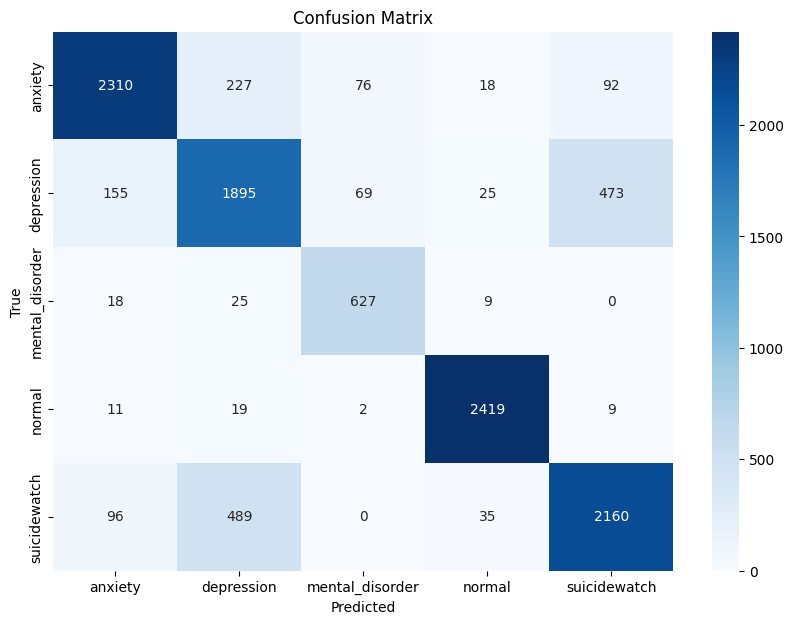

In [ ]:
import pickle
label_encodings= pickle.load(open('/content/drive/MyDrive/mini project/label_encodings1.pkl', 'rb'))
predicted_labels = np.argmax(predictions, axis=1)

print (classification_report(test_labels, predicted_labels, target_names = label_encodings.classes_))

cm = confusion_matrix(test_labels, predicted_labels)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels= label_encodings.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
predicted_labels = np.argmax(predictions, axis=1)
print("Unique predictions:", set(predicted_labels))
print(pd.Series(predicted_labels).value_counts())

Unique predictions: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)}
4    2734
1    2655
0    2590
3    2506
2     774
Name: count, dtype: int64


In [ ]:
import torch

def detection(text):
    text = clean_statement(text)

    model.eval()  # important

    device = next(model.parameters()).device

    inputs = tokenizer(
        text,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=256   # match training
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():  # important
        outputs = model(**inputs)

    logits = outputs.logits
    probs = torch.softmax(logits, dim=1)

    predicted_label = torch.argmax(probs, dim=1).item()
    confidence = probs.max().item()

    label = label_encodings.inverse_transform([predicted_label])[0]

    return {
        "label": label,
        "confidence": round(confidence, 3)
    }

In [ ]:
import torch

def detection_top2(text):
    text = clean_statement(text)

    model.eval()

    device = next(model.parameters()).device

    inputs = tokenizer(
        text,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=256
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    probs = torch.softmax(logits, dim=1)

    # Top 2 predictions
    top2 = torch.topk(probs, 2)

    top_labels = []
    top_confidences = []

    for i in range(2):
        label_index = top2.indices[0][i].item()
        confidence = top2.values[0][i].item()

        label = label_encodings.inverse_transform([label_index])[0]

        top_labels.append(label)
        top_confidences.append(round(confidence, 3))

    return {
        "top_1": {"label": top_labels[0], "confidence": top_confidences[0]},
        "top_2": {"label": top_labels[1], "confidence": top_confidences[1]}
    }

In [ ]:
sample_texts = [
"I feel perfectly fine today, nothing to worry about.",
"I can't stop thinking about what will happen if things go wrong.",
"Lately, I've been on a high, feeling like I can do anything!",
"I'm so sad, I just can't seem to get out of bed anymore.",
"I'm constantly thinking about how much better everyone else is doing than me.",
"I don't think I can keep going, everything feels so hopeless.",
"I had a really good day, spent some time with my friends.",
"I'm overwhelmed by the idea that I might lose everything.",
"I feel like nothing matters anymore, I just want to give up.",
"I'm okay today, but sometimes I get really anxious for no reason."]

for text in sample_texts:
  predicted_class1 = detection(text)
  predicted_class2 = detection_top2(text)
  print(f"Text: {text}\nPredicted Class: {predicted_class1}\n")
  print(f"Text: {text}\nPredicted Class: {predicted_class2}\n")
  print("_________________________________")


Text: I feel perfectly fine today, nothing to worry about.
Predicted Class: {'label': 'anxiety', 'confidence': 0.748}

Text: I feel perfectly fine today, nothing to worry about.
Predicted Class: {'top_1': {'label': 'anxiety', 'confidence': 0.748}, 'top_2': {'label': 'normal', 'confidence': 0.205}}

_________________________________
Text: I can't stop thinking about what will happen if things go wrong.
Predicted Class: {'label': 'normal', 'confidence': 0.985}

Text: I can't stop thinking about what will happen if things go wrong.
Predicted Class: {'top_1': {'label': 'normal', 'confidence': 0.985}, 'top_2': {'label': 'depression', 'confidence': 0.005}}

_________________________________
Text: Lately, I've been on a high, feeling like I can do anything!
Predicted Class: {'label': 'normal', 'confidence': 0.982}

Text: Lately, I've been on a high, feeling like I can do anything!
Predicted Class: {'top_1': {'label': 'normal', 'confidence': 0.982}, 'top_2': {'label': 'mental_disorder', 'confi

In [ ]:
sample_texts = [
    "I have been overthinking every single decision I make lately and my heart just races for no reason at all, I cant sleep because my brain wont stop",
    "I have no energy to do anything anymore, I just lay in bed all day and nothing brings me joy, I dont see the point of trying",
    "I am so tired of waking up every day feeling like this, I dont want to be here anymore and I keep thinking about ending it all",
    "had a pretty chill weekend, went grocery shopping and watched some movies, feeling okay about the week ahead",
    "I keep hearing voices telling me to do things and sometimes I genuinely cannot tell what is real and what isnt, its been going on for weeks",
    "I snapped at my coworker today over nothing and now I cant stop replaying it, why do I always do this",
    "been feeling really low for months now, lost my job and my girlfriend left, I just dont care about anything anymore",
    "my thoughts are going a mile a minute I feel like I can conquer everything today but yesterday I couldnt get out of bed",
    "I know its irrational but I genuinely cannot stop worrying that something bad is going to happen to my family",
    "honestly feel nothing lately, not sad not happy just completely empty, like I am just going through the motions"
]

for text in sample_texts:
  predicted_class = detection(text)
  print(f"Text: {text}\nPredicted Class: {predicted_class}\n")

Text: I have been overthinking every single decision I make lately and my heart just races for no reason at all, I cant sleep because my brain wont stop
Predicted Class: {'label': 'depression', 'confidence': 0.513}

Text: I have no energy to do anything anymore, I just lay in bed all day and nothing brings me joy, I dont see the point of trying
Predicted Class: {'label': 'depression', 'confidence': 0.872}

Text: I am so tired of waking up every day feeling like this, I dont want to be here anymore and I keep thinking about ending it all
Predicted Class: {'label': 'depression', 'confidence': 0.884}

Text: had a pretty chill weekend, went grocery shopping and watched some movies, feeling okay about the week ahead
Predicted Class: {'label': 'normal', 'confidence': 0.991}

Text: I keep hearing voices telling me to do things and sometimes I genuinely cannot tell what is real and what isnt, its been going on for weeks
Predicted Class: {'label': 'depression', 'confidence': 0.688}

Text: I sna

In [ ]:
text = "There's this constant low hum of dread that follows me through the day — not attached to anything specific, not a fear of losing my job or a worry about my health, just a free-floating heaviness that settles over everything like weather, making even neutral moments feel slightly ominous, and I've gotten so used to it that I barely notice it anymore except in the rare moments when it lifts briefly and I suddenly remember what it felt like to just exist without carrying something"
detection(text)

{'label': 'mental_disorder', 'confidence': 0.728}